# Hit Clustering

In [1]:
import h5py as h5
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import glob
plt.style.use('../../utils/dune.mplstyle')

import sys, os

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(repo_root)

from utils.backtracking import get_charge_event_hits, hit_backtracker, get_ancestry # Now this works
from utils.my_ev_display import event_display

### Load Data (MC+Cosmic Overlap)

In [2]:
cosmic_data = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_charge/ColdOperations/data/2025_Operations_Cold/source/AmBe_noSource_2/packet-0060105-2025_11_11_12_01_45_CST.FLOW.hdf5'
MC_data = '/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_tests/2x2_AmBe_in_mod2_prompt_window_test_11-19-2025_MOD.FLOW.hdf5'

In [3]:
# Notes on design of overlap_MC_Cosmic():
# Should achieve: Given arbitrarily many cosmic/MC files, overlap them on an event by event basis
# The output should be a list of overlapped event point clouds, with each point having a label for their interaction type (or is cosmic)

In [4]:
def overlap_MC_Cosmic(cosmic_file, MC_file):
    '''
    Overlap each MC event with a cosmic trigger
    
    If there are less cosmic triggers than MC events there will be a notice of how many events were successfully overlapped
    '''

    # Load cosmic data
    cosmic_hit_E = []
    cosmic_hit_location = []
    cosmic_hit_iogroup = []
    cosmic_hit_evtid = []

    for file in glob.iglob(cosmic_file):
        with h5.File(file, 'r') as f:
            # Filter out hits with negative energy (likley from noisy pixels) for now
            positive_hits = f['charge/calib_prompt_hits/data'][f['charge/calib_prompt_hits/data']['E']>0]
            cosmic_hit_E.extend(positive_hits['E'])
            cosmic_hit_location.extend(np.column_stack([np.array(positive_hits['ts_pps']), np.array(positive_hits['x']), np.array(positive_hits['y']), np.array(positive_hits['z'])]))
            cosmic_hit_iogroup.extend(positive_hits['io_group'])
            for i in range(len(positive_hits)):
                # Obtain the event id of each hit using the reference between calib_prompt_hits and charge/events
                ref_region_temp = f['charge/calib_prompt_hits/ref/charge/events/ref_region'][positive_hits['id'][i]]
                cosmic_hit_evtid.append(np.unique(f['charge/events/ref/charge/calib_prompt_hits/ref'][ref_region_temp[0]:ref_region_temp[1],0][f['charge/events/ref/charge/calib_prompt_hits/ref'][ref_region_temp[0]:ref_region_temp[1],1]==positive_hits['id'][i]])[0])

    cosmic_hit_E = np.array(cosmic_hit_E)
    cosmic_hit_location = np.array(cosmic_hit_location)
    cosmic_hit_iogroup = np.array(cosmic_hit_iogroup)
    cosmic_hit_evtid = np.array(cosmic_hit_evtid)

    # Load MC
    mc_hit_E = []
    mc_hit_location = []
    mc_hit_evtid = []
    mc_hit_n_process = []

    for file in glob.iglob(MC_file):
        with h5.File(file, 'r') as f:
            traj = f['mc_truth/trajectories/data']
            seg = f['mc_truth/segments/data']
            for event_id in np.unique(traj['event_id']):
                my_entry = event_id-1
                ev_traj= traj[traj['event_id']==event_id]
                ev_seg= seg[seg['event_id']==event_id]
                prompt_hits_backtrack, prompt_hits = get_charge_event_hits(my_entry,f)
                new_hits = hit_backtracker(prompt_hits_backtrack, prompt_hits, ev_seg, ev_traj)

                # Exclude negative hits
                positive_hits = new_hits[new_hits['E']>=0]
                mc_hit_E.extend(positive_hits['E'])
                mc_hit_location.extend(np.column_stack([positive_hits['ts_pps'], positive_hits['x'], positive_hits['y'], positive_hits['z']]))
                mc_hit_evtid.extend([event_id for i in range(len(positive_hits['E']))])
                mc_hit_n_process.extend(positive_hits['neutron_process'])

    mc_hit_E = np.array(mc_hit_E)
    mc_hit_location = np.array(mc_hit_location)
    mc_hit_evtid = np.array(mc_hit_evtid)
    mc_hit_n_process = np.array(mc_hit_n_process)

    # Combine the two dataset
    overlapped_E = []
    overlapped_location = []
    overlapped_evtid = []
    overlapped_n_process = []

    evtid_temp = np.unique(mc_hit_evtid)
    for i in range(min([len(np.unique(cosmic_hit_evtid)), len(np.unique(mc_hit_evtid))])):
        overlapped_E.extend(np.hstack([mc_hit_E[mc_hit_evtid==evtid_temp[i]], cosmic_hit_E[cosmic_hit_evtid==evtid_temp[i]]]))
        overlapped_location.extend(np.vstack([mc_hit_location[mc_hit_evtid==evtid_temp[i]], cosmic_hit_location[cosmic_hit_evtid==evtid_temp[i]]]))
        overlapped_evtid.extend(np.hstack([mc_hit_evtid[mc_hit_evtid==evtid_temp[i]], cosmic_hit_evtid[cosmic_hit_evtid==evtid_temp[i]]]))
        overlapped_n_process.extend(np.hstack([mc_hit_n_process[mc_hit_evtid==evtid_temp[i]], -1*np.ones(len(cosmic_hit_E[cosmic_hit_evtid==evtid_temp[i]]))]))

    return np.array(overlapped_E), np.array(overlapped_location), np.array(overlapped_evtid), np.array(overlapped_n_process)

In [5]:
# Generate data
E_overlapped, loc_overlapped, evtid_overlapped, n_process_overlapped = overlap_MC_Cosmic(cosmic_data, MC_data)

# Physical constants for analysis
# Drift velocity in :math:`cm/\mu s`
V_DRIFT = 0.1648 # cm / us
t_per_tick = 0.1 # us / tick

# Convert time dimension to drift distance using drift velocity
loc_overlapped[:,0] *= V_DRIFT*t_per_tick

### Scan DBScan parameters optimize the clustering

In [6]:
# Import packages for clustering

from sklearn.cluster import DBSCAN

In [31]:
def cluster_hits(locs, evt_ids, process_labels, cluster_size, Eps, output_label=False, cluster_3d=False):
    '''
    Perform DBScan on hits from each event and produce performance figures

    Input

    locs: 3d location of hits + drift time
    evt_ids: event id of hits
    process_labels: process labels of hits
                    -1 == Data
                     0 == Inelastic
                     1 == Capture
                     2 == Non-neutron hit
    cluster_size: DBScan parameter, minimum number of data points in a cluster
    Eps: DBScan parameter epsilon, maximum radius of a neighborhood around a data point
    output_label: True == Include the variable hit_labels in output
                  False == Not include the variable hit_labels in output
    cluster_3d: True == Cluster with 3d hit location data
                False == Cluster with 3d hit location data + drift time


    Output
    
    avg_eff: average efficiency per event
    avg_pur: average purity per event
    nclust: number of clusters per event
    mchit_percentage: percentage of simulated hits per event
    hit_labels: The cluster labels from DBScan
                -2 == Invalid hit location in event, hits not clustered
                -1 == Hit not clustered, noise points
    '''

    hit_labels = []
    event_efficiency = []
    event_purity = []
    ncluster = []

    # Iterate over events
    for index,i in enumerate([locs[evt_ids==l] for l in np.unique(evt_ids)]):
        if any(np.isnan(i[:,0]))==True or any(np.isnan(i[:,1]))==True or any(np.isnan(i[:,2]))==True or any(np.isnan(i[:,3]))==True:
            print('invalid hit location in event')
            # Filter out the nan hits and apply DBSCAN
            nan_mask = np.isnan(i).any(axis=1)
            hit_labels_temp = -2*np.ones(len(i))
            if cluster_3d:
                capt_db = DBSCAN(eps=Eps, min_samples=cluster_size, algorithm='kd_tree').fit(i[~nan_mask][:,1:])
            else:
                capt_db = DBSCAN(eps=Eps, min_samples=cluster_size, algorithm='kd_tree').fit(i[~nan_mask])
            capt_cluster_label = capt_db.labels_
            hit_labels_temp[~nan_mask] = capt_cluster_label
            hit_labels.extend(hit_labels_temp)
        else:
            # Apply DBScan
            if cluster_3d:
                capt_db = DBSCAN(eps=Eps, min_samples=cluster_size, algorithm='kd_tree').fit(i[:,:2])
            else:
                capt_db = DBSCAN(eps=Eps, min_samples=cluster_size, algorithm='kd_tree').fit(i)
            hit_labels_temp = capt_db.labels_
            hit_labels.extend(hit_labels_temp)

        # Calculate the efficiency and purity event by event
        event_process = process_labels[evt_ids==np.unique(evt_ids)[index]]
        clustered_evt_process = event_process[hit_labels_temp!=-1]
        if len(hit_labels_temp[~np.isin(hit_labels_temp, [-1, -2])])==0 or len(event_process[event_process==1])==0:
            pass
        else:
            event_efficiency.append(len(clustered_evt_process[clustered_evt_process==1])/len(event_process[event_process==1]))
            event_purity.append(len(clustered_evt_process[clustered_evt_process==1])/len(hit_labels_temp[~np.isin(hit_labels_temp, [-1, -2])]))
            ncluster.append(len(set(hit_labels_temp) - {-1} - {-2}))

    avg_eff = np.average(event_efficiency)
    avg_pur = np.average(event_purity)
    nclust = np.average(ncluster)
    mchit_percentage = len(process_labels[process_labels!=-1])/len(process_labels)

    if output_label:
        hit_labels = np.array(hit_labels)
        return avg_eff, avg_pur, nclust, mchit_percentage, hit_labels
    else:
        return avg_eff, avg_pur, nclust, mchit_percentage

In [38]:
# Array of DBScan test parameters

cluster_size_list = np.arange(3,11,1)
eps_list = np.arange(1,20,2)

In [ ]:
avg_eff_per_evt = []
avg_pur_per_evt = []
ncluster_per_evt = []
percentage_mchits = []

for m in cluster_size_list:
    for n in eps_list:
        eff,pur,nc,per = cluster_hits(loc_overlapped, evtid_overlapped, n_process_overlapped, m, n)
        avg_eff_per_evt.append(eff)
        avg_pur_per_evt.append(pur)
        ncluster_per_evt.append(nc)
        percentage_mchits.append(per)

invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hi

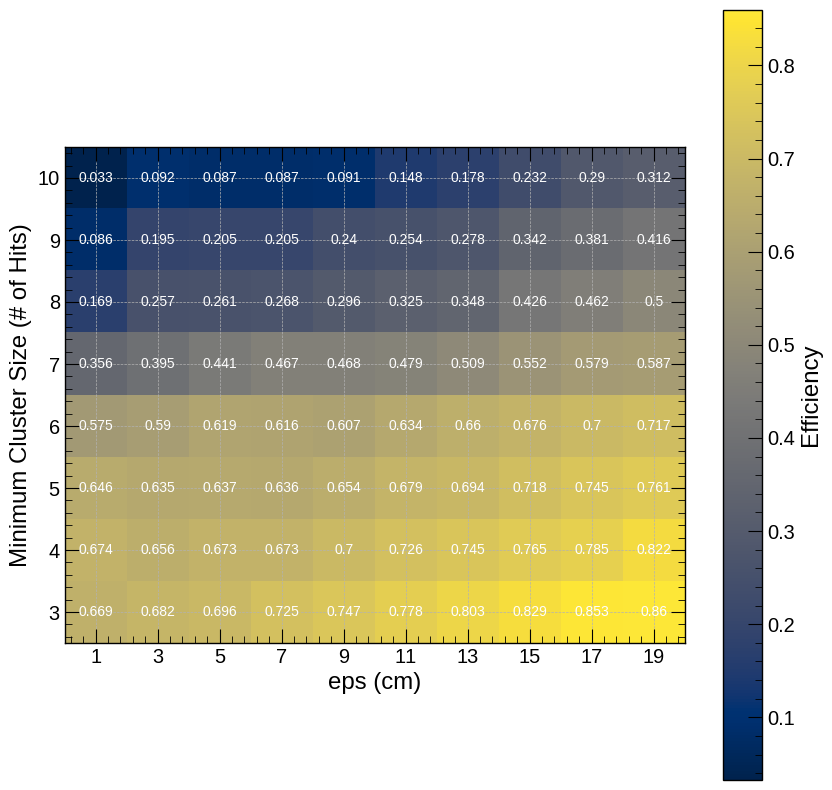

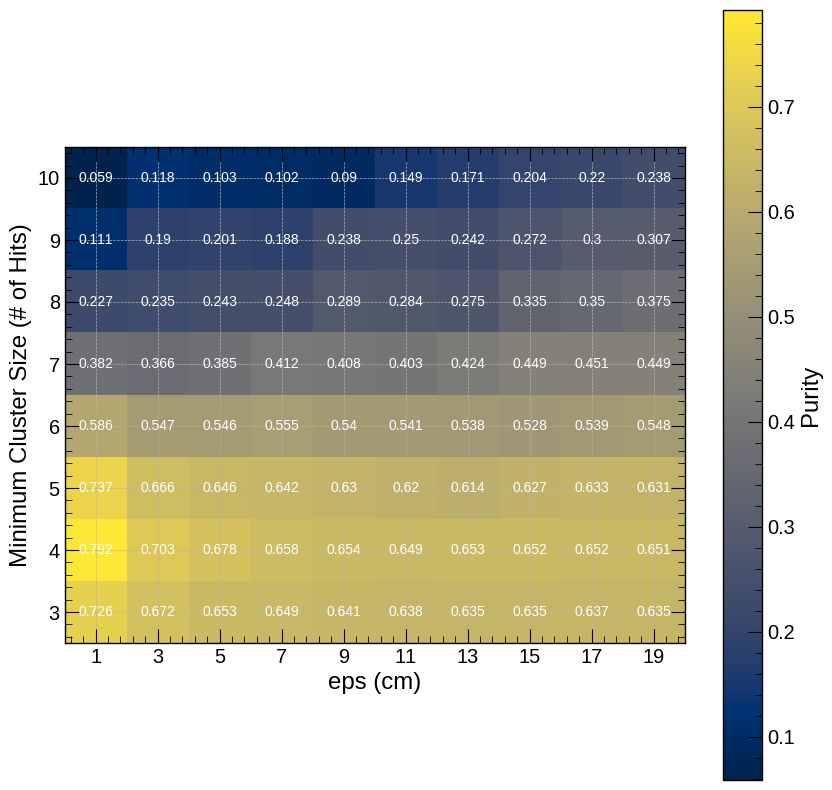

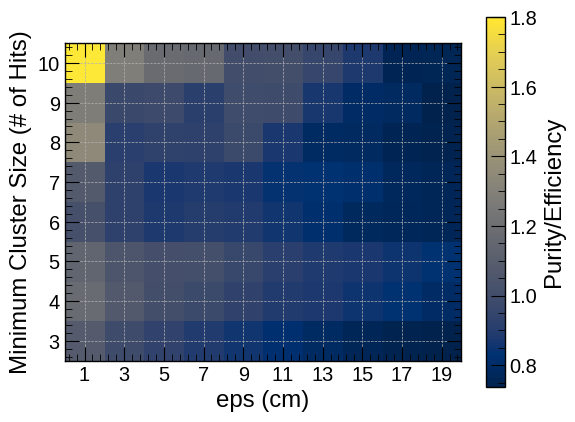

In [10]:
# Generate a 2d histogram of the efficiency and purity

# Turn the list of effciency and purity into 2d arrays
# eps varies across rows, cluster size vary across columns

eff_array = np.reshape(avg_eff_per_evt, (len(cluster_size_list), len(eps_list)))
pur_array = np.reshape(avg_pur_per_evt, (len(cluster_size_list), len(eps_list)))


# Efficiency
plt.figure(figsize=(10, 10))
plt.imshow(eff_array, origin='lower')
plt.colorbar(label='Efficiency')
plt.xlabel('eps (cm)')
plt.ylabel('Minimum Cluster Size (# of Hits)')
plt.yticks(ticks=np.arange(0,len(cluster_size_list),1), labels=cluster_size_list)
plt.xticks(ticks=np.arange(0,len(eps_list),1), labels=eps_list)
#plt.title('Average Efficiency per Event')
plt.grid(True)

# Loop over data dimensions and create text annotations.
for i in range(len(cluster_size_list)):
    for j in range(len(eps_list)):
        text = plt.text(j, i, eff_array[i, j].round(3),
                       ha="center", va="center", color="w")

plt.show()


# Purity
plt.figure(figsize=(10, 10))
plt.imshow(pur_array, origin='lower')
plt.colorbar(label='Purity')
plt.xlabel('eps (cm)')
plt.ylabel('Minimum Cluster Size (# of Hits)')
plt.yticks(ticks=np.arange(0,len(cluster_size_list),1), labels=cluster_size_list)
plt.xticks(ticks=np.arange(0,len(eps_list),1), labels=eps_list)
#plt.title('Average Purity per Event')
plt.grid(True)

# Loop over data dimensions and create text annotations.
for i in range(len(cluster_size_list)):
    for j in range(len(eps_list)):
        text = plt.text(j, i, pur_array[i, j].round(3),
                       ha="center", va="center", color="w")

plt.show()

# Purity/Efficiency
plt.imshow(pur_array/eff_array, origin='lower')
plt.colorbar(label='Purity/Efficiency')
plt.xlabel('eps (cm)')
plt.ylabel('Minimum Cluster Size (# of Hits)')
plt.yticks(ticks=np.arange(0,len(cluster_size_list),1), labels=cluster_size_list)
plt.xticks(ticks=np.arange(0,len(eps_list),1), labels=eps_list)
#plt.title('Purity/Efficiency per Event')
plt.grid(True)
plt.show()

#### Try finer binning

In [11]:
# Array of DBScan test parameters

cluster_size_list = np.arange(3,7,1)
eps_list_fine = np.arange(1,3,0.1).round(1)

In [12]:
avg_eff_per_evt = []
avg_pur_per_evt = []
ncluster_per_evt = []
percentage_mchits = []

for m in cluster_size_list:
    for n in eps_list_fine:
        eff,pur,nc,per = cluster_hits(loc_overlapped, evtid_overlapped, n_process_overlapped, m, n)
        avg_eff_per_evt.append(eff)
        avg_pur_per_evt.append(pur)
        ncluster_per_evt.append(nc)
        percentage_mchits.append(per)

invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hi

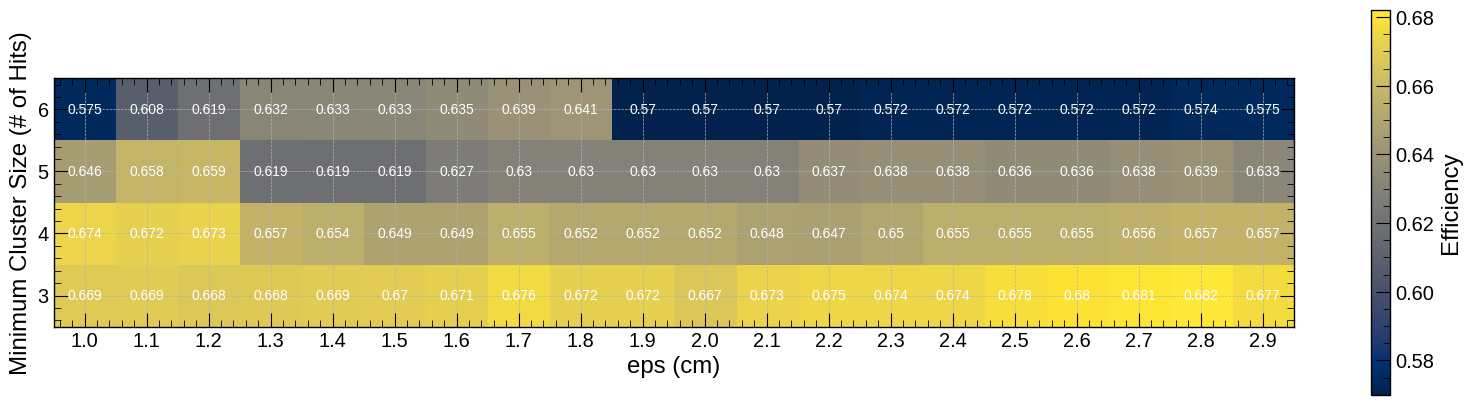

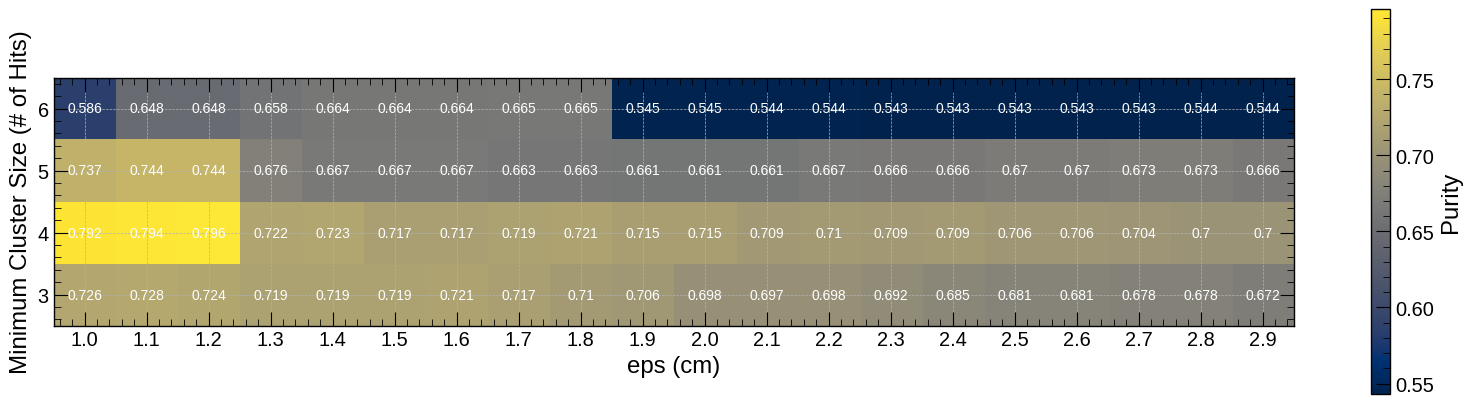

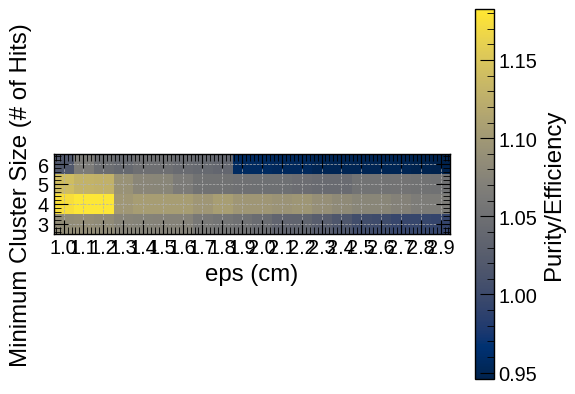

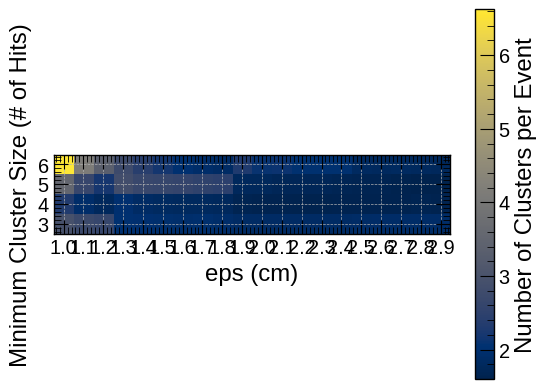

In [13]:
# Generate a 2d histogram of the efficiency and purity

# Turn the list of effciency and purity into 2d arrays
# eps varies across rows, cluster size vary across columns

eff_array = np.reshape(avg_eff_per_evt, (len(cluster_size_list), len(eps_list_fine)))
pur_array = np.reshape(avg_pur_per_evt, (len(cluster_size_list), len(eps_list_fine)))

# Efficiency
plt.figure(figsize=(20, 5))
plt.imshow(eff_array, origin='lower')
plt.colorbar(label='Efficiency')
plt.xlabel('eps (cm)')
plt.ylabel('Minimum Cluster Size (# of Hits)')
plt.yticks(ticks=np.arange(0,len(cluster_size_list),1), labels=cluster_size_list)
plt.xticks(ticks=np.arange(0,len(eps_list_fine),1), labels=eps_list_fine)
#plt.title('Average Efficiency per Event')
plt.grid(True)

# Loop over data dimensions and create text annotations.
for i in range(len(cluster_size_list)):
    for j in range(len(eps_list_fine)):
        text = plt.text(j, i, eff_array[i, j].round(3),
                       ha="center", va="center", color="w")

plt.show()

# Purity
plt.figure(figsize=(20, 5))
plt.imshow(pur_array, origin='lower')
plt.colorbar(label='Purity')
plt.xlabel('eps (cm)')
plt.ylabel('Minimum Cluster Size (# of Hits)')
plt.yticks(ticks=np.arange(0,len(cluster_size_list),1), labels=cluster_size_list)
plt.xticks(ticks=np.arange(0,len(eps_list_fine),1), labels=eps_list_fine)
#plt.title('Average Purity per Event')
plt.grid(True)

# Loop over data dimensions and create text annotations.
for i in range(len(cluster_size_list)):
    for j in range(len(eps_list_fine)):
        text = plt.text(j, i, pur_array[i, j].round(3),
                       ha="center", va="center", color="w")

plt.show()

# Purity/Efficiency
plt.imshow(pur_array/eff_array, origin='lower')
plt.colorbar(label='Purity/Efficiency')
plt.xlabel('eps (cm)')
plt.ylabel('Minimum Cluster Size (# of Hits)')
plt.yticks(ticks=np.arange(0,len(cluster_size_list),1), labels=cluster_size_list)
plt.xticks(ticks=np.arange(0,len(eps_list_fine),1), labels=eps_list_fine)
#plt.title('Purity/Efficiency per Event')
plt.grid(True)
plt.show()


# Distribution of Number of Clusters per events

ncluster_array = np.reshape(ncluster_per_evt, (len(cluster_size_list), len(eps_list_fine)))

plt.imshow(ncluster_array, origin='lower')
plt.colorbar(label='Number of Clusters per Event')
plt.xlabel('eps (cm)')
plt.ylabel('Minimum Cluster Size (# of Hits)')
plt.yticks(ticks=np.arange(0,len(cluster_size_list),1), labels=cluster_size_list)
plt.xticks(ticks=np.arange(0,len(eps_list_fine),1), labels=eps_list_fine)
#plt.title('Purity/Efficiency per Event')
plt.grid(True)
plt.show()

In [33]:
# Conduct the same clustering tests with 3d hit information

avg_eff_per_evt = []
avg_pur_per_evt = []
ncluster_per_evt = []
percentage_mchits = []

for m in cluster_size_list:
    for n in eps_list:
        eff,pur,nc,per = cluster_hits(loc_overlapped, evtid_overlapped, n_process_overlapped, m, n, cluster_3d=True)
        avg_eff_per_evt.append(eff)
        avg_pur_per_evt.append(pur)
        ncluster_per_evt.append(nc)
        percentage_mchits.append(per)

invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hi

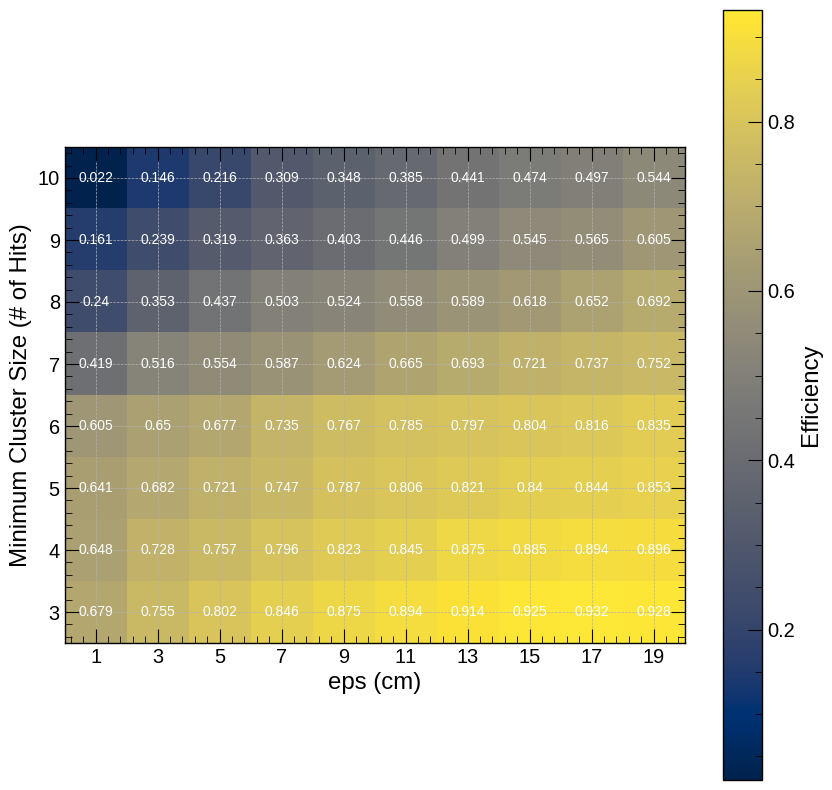

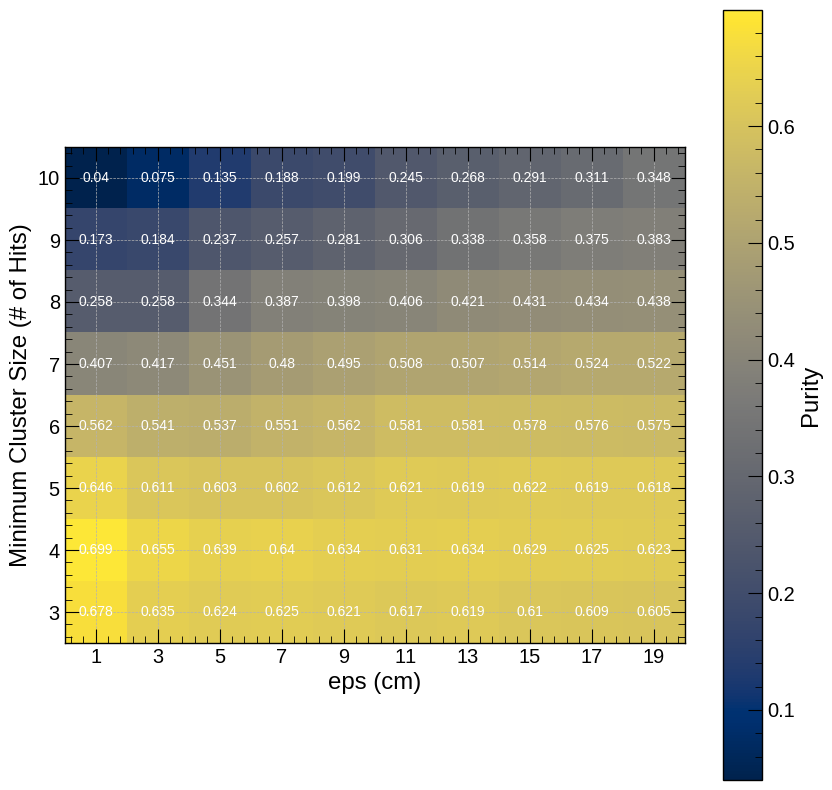

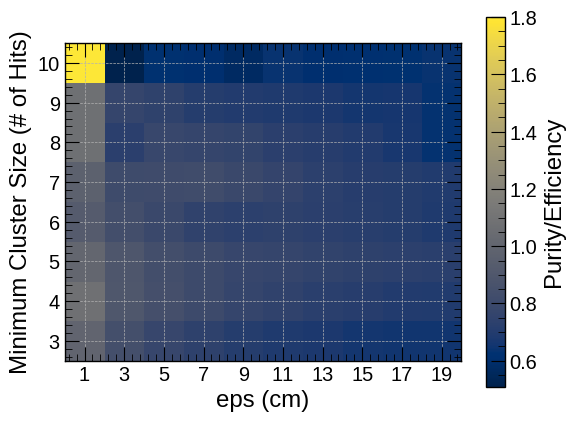

In [34]:
# Generate a 2d histogram of the efficiency and purity

# Turn the list of effciency and purity into 2d arrays
# eps varies across rows, cluster size vary across columns

eff_array = np.reshape(avg_eff_per_evt, (len(cluster_size_list), len(eps_list)))
pur_array = np.reshape(avg_pur_per_evt, (len(cluster_size_list), len(eps_list)))


# Efficiency
plt.figure(figsize=(10, 10))
plt.imshow(eff_array, origin='lower')
plt.colorbar(label='Efficiency')
plt.xlabel('eps (cm)')
plt.ylabel('Minimum Cluster Size (# of Hits)')
plt.yticks(ticks=np.arange(0,len(cluster_size_list),1), labels=cluster_size_list)
plt.xticks(ticks=np.arange(0,len(eps_list),1), labels=eps_list)
#plt.title('Average Efficiency per Event')
plt.grid(True)

# Loop over data dimensions and create text annotations.
for i in range(len(cluster_size_list)):
    for j in range(len(eps_list)):
        text = plt.text(j, i, eff_array[i, j].round(3),
                       ha="center", va="center", color="w")

plt.show()


# Purity
plt.figure(figsize=(10, 10))
plt.imshow(pur_array, origin='lower')
plt.colorbar(label='Purity')
plt.xlabel('eps (cm)')
plt.ylabel('Minimum Cluster Size (# of Hits)')
plt.yticks(ticks=np.arange(0,len(cluster_size_list),1), labels=cluster_size_list)
plt.xticks(ticks=np.arange(0,len(eps_list),1), labels=eps_list)
#plt.title('Average Purity per Event')
plt.grid(True)

# Loop over data dimensions and create text annotations.
for i in range(len(cluster_size_list)):
    for j in range(len(eps_list)):
        text = plt.text(j, i, pur_array[i, j].round(3),
                       ha="center", va="center", color="w")

plt.show()

# Purity/Efficiency
plt.imshow(pur_array/eff_array, origin='lower')
plt.colorbar(label='Purity/Efficiency')
plt.xlabel('eps (cm)')
plt.ylabel('Minimum Cluster Size (# of Hits)')
plt.yticks(ticks=np.arange(0,len(cluster_size_list),1), labels=cluster_size_list)
plt.xticks(ticks=np.arange(0,len(eps_list),1), labels=eps_list)
#plt.title('Purity/Efficiency per Event')
plt.grid(True)
plt.show()

#### Compare Energy Distribution of Clusters vs Truth

Tentative optimal setting for DBSCAN: eps = 1cm, minimum cluster size = 4hits

In [36]:
optimum_eps = 1
optimum_clustersize = 4

# Cluster using optimized DBSCAN parameter
efficiency,purity,ncluster,mc_hit_percentage,cluster_label = cluster_hits(loc_overlapped, evtid_overlapped, n_process_overlapped, optimum_clustersize, optimum_eps, output_label=True)

invalid hit location in event


In [37]:
print(f'Efficiency: {efficiency}')
print(f'Purity: {purity}')

Efficiency: 0.674140958683626
Purity: 0.7922003264443823


In [16]:
def get_cluster_energy(evtid, E, clust_label):
    '''
    Calculate total energy of all clustered hits in an event
    '''
    clust_E = []

    for i in set(evtid):
        evt_E = E[evtid==i]
        evt_clust_label = clust_label[evtid==i]
        c_E = []
        for j in set(evt_clust_label) - {-1} - {-2}:
            c_E.append(sum(evt_E[evt_clust_label==j]))
        if len(c_E):
            clust_E.append(sum(c_E))
        else:
            pass
    clust_E = np.array(clust_E)

    return clust_E


def get_truth_energy(evtid, E, truth_label):
    '''
    Calculate the total energy of all truth-level hits generated by neutron capture in each event
    '''
    truth_E = []

    for i in set(evtid):
        evt_E = E[evtid==i]
        evt_truth_label = truth_label[evtid==i]
        truth_E.append(sum(evt_E[evt_truth_label==1]))
    truth_E = np.array(truth_E)
    
    return truth_E

In [17]:
# Get the per event cluster and truth energy from capture of the overlapped dataset

E_cluster = get_cluster_energy(evtid_overlapped, E_overlapped, cluster_label)
E_truth = get_truth_energy(evtid_overlapped, E_overlapped, n_process_overlapped)

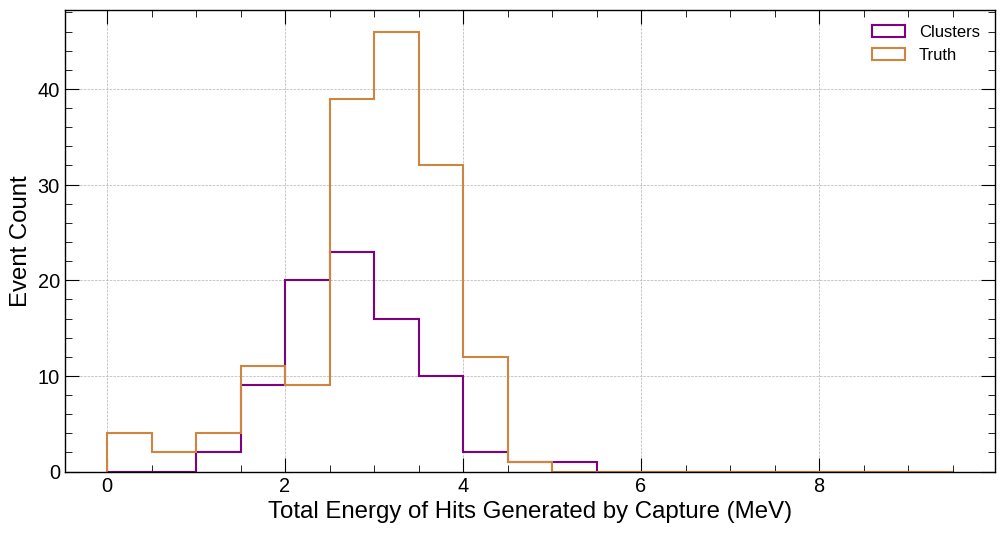

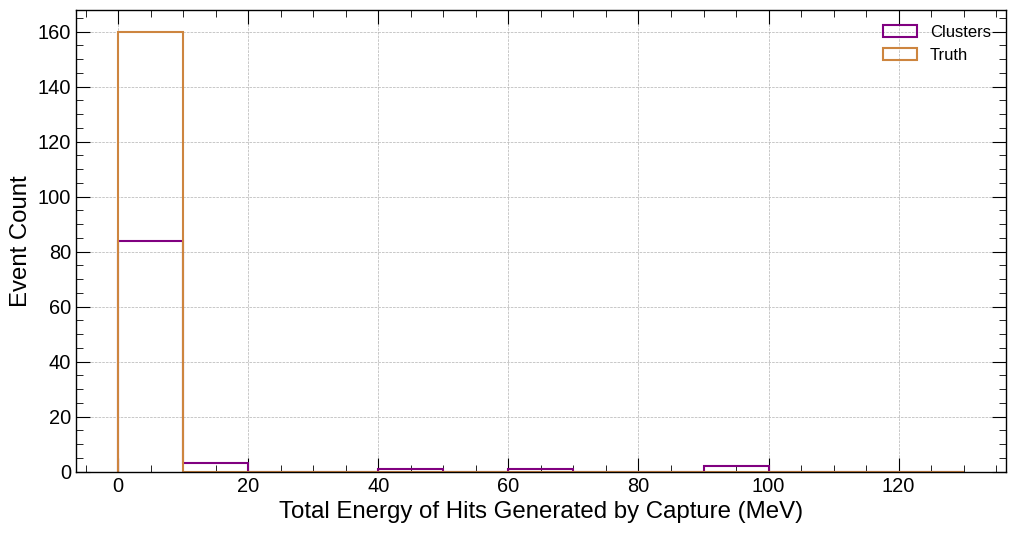

In [18]:
# Show the ditribution of clustered vs truth energies

plt.figure(figsize=(12, 6))

plt.hist(E_cluster, color='purple', histtype='step', bins=np.arange(0,10,0.5), label='Clusters')
plt.hist(E_truth, color='peru', histtype='step', bins=np.arange(0,10,0.5), label='Truth')

plt.xlabel('Total Energy of Hits Generated by Capture (MeV)')
plt.ylabel('Event Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))

plt.hist(E_cluster, color='purple', histtype='step', bins=np.arange(0,140,10), label='Clusters')
plt.hist(E_truth, color='peru', histtype='step', bins=np.arange(0,140,10), label='Truth')

plt.xlabel('Total Energy of Hits Generated by Capture (MeV)')
plt.ylabel('Event Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

In [19]:
# Apply the same clustering to just the background used in this overlap

# Cluster using optimized DBSCAN parameter
efficiency_bkg,purity_bkg,ncluster_bkg,mc_hit_percentage_bkg,cluster_label_bkg = cluster_hits(loc_overlapped[n_process_overlapped==-1], evtid_overlapped[n_process_overlapped==-1], n_process_overlapped[n_process_overlapped==-1], optimum_clustersize, optimum_eps, output_label=True)

# Purity and Efficiecy should both be 0
print(efficiency)
print(purity)

invalid hit location in event
0.674140958683626
0.7922003264443823


/global/homes/e/edgarmao/.local/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/global/homes/e/edgarmao/.local/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [20]:
# Get the per event cluster and truth energy from capture of the bkg dataset

E_cluster_bkg = get_cluster_energy(evtid_overlapped[n_process_overlapped==-1], E_overlapped[n_process_overlapped==-1], cluster_label[n_process_overlapped==-1])

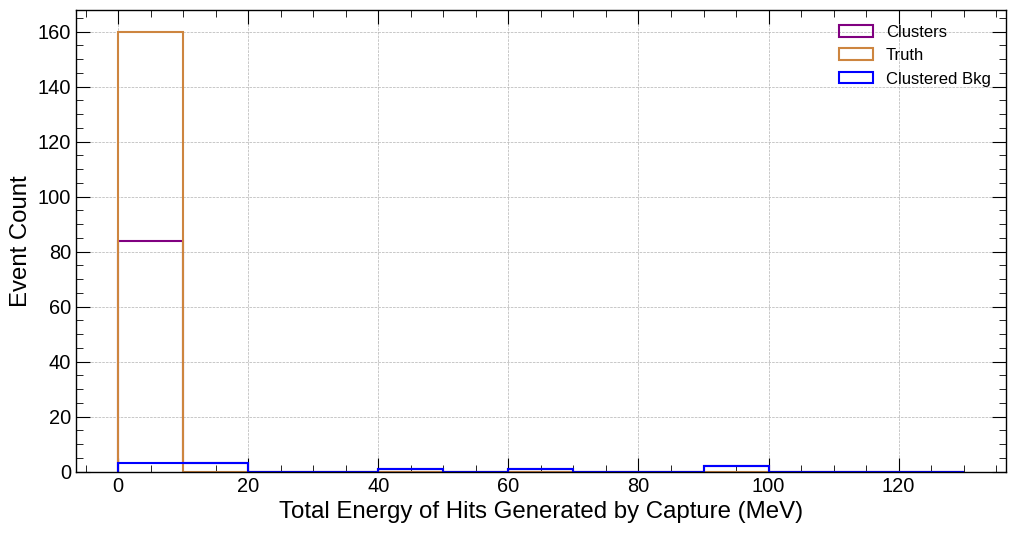

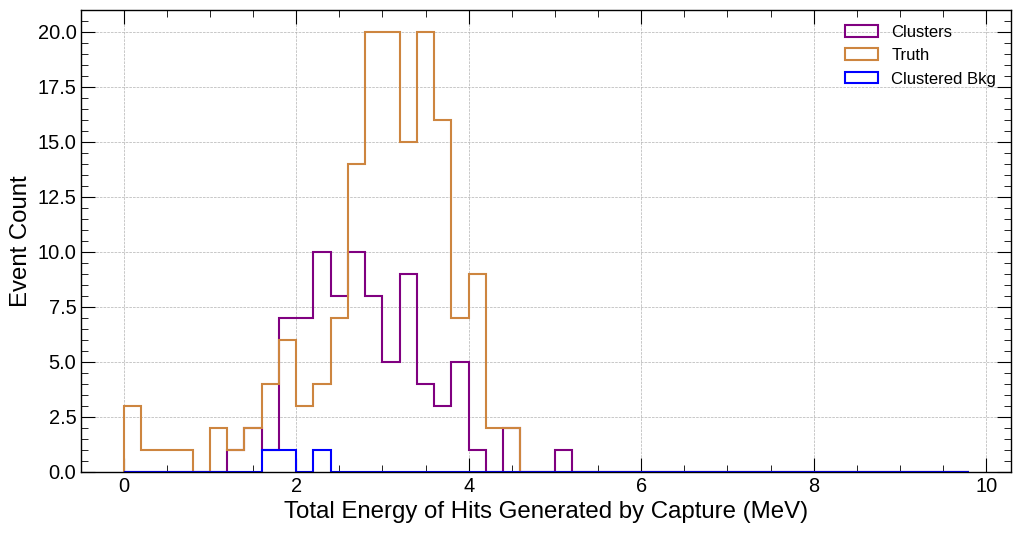

In [21]:
# Energy distribution of the clustered background in comparison to truth and clustering results of the overlapped dataset

plt.figure(figsize=(12, 6))

plt.hist(E_cluster, color='purple', histtype='step', bins=np.arange(0,140,10), label='Clusters')
plt.hist(E_truth, color='peru', histtype='step', bins=np.arange(0,140,10), label='Truth')
plt.hist(E_cluster_bkg, color='blue', histtype='step', bins=np.arange(0,140,10), label='Clustered Bkg')

plt.xlabel('Total Energy of Hits Generated by Capture (MeV)')
plt.ylabel('Event Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()


plt.figure(figsize=(12, 6))

plt.hist(E_cluster, color='purple', histtype='step', bins=np.arange(0,10,0.2), label='Clusters')
plt.hist(E_truth, color='peru', histtype='step', bins=np.arange(0,10,0.2), label='Truth')
plt.hist(E_cluster_bkg, color='blue', histtype='step', bins=np.arange(0,10,0.2), label='Clustered Bkg')

plt.xlabel('Total Energy of Hits Generated by Capture (MeV)')
plt.ylabel('Event Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

In [22]:
def cluster_Ecut(c_label, hitE, evtids, nprocess, cut:float):
    '''Make an energy cut and output the purity and efficiency of data above and below the cut'''

    Elow = []
    Ehigh = []
    pur_low = []
    pur_high = []
    eff_low = []
    eff_high = []

    for i in np.unique(evtids):
        evt_c_label = c_label[evtids==i]
        evt_nprocess = nprocess[evtids==i]
        evt_E = hitE[evtids==i]

        c_nprocess = []
        c_E = []

        for j in set(evt_c_label)-{-1}-{-2}:
            c_nprocess.extend(evt_nprocess[evt_c_label==j])
            c_E.extend(evt_E[evt_c_label==j])
        
        c_nprocess = np.array(c_nprocess)

        if sum(c_E)<=cut and len(evt_nprocess[evt_nprocess==1])!=0 and len(evt_c_label[~np.isin(evt_c_label, [-1, -2])])!=0 and len(c_E):
            eff_low.append(len(c_nprocess[c_nprocess==1])/len(evt_nprocess[evt_nprocess==1]))
            pur_low.append(len(c_nprocess[c_nprocess==1])/len(evt_c_label[~np.isin(evt_c_label, [-1, -2])]))
            Elow.append(sum(c_E))
        elif sum(c_E)>cut and len(evt_nprocess[evt_nprocess==1])!=0 and len(evt_c_label[~np.isin(evt_c_label, [-1, -2])])!=0 and len(c_E):
            eff_high.append(len(c_nprocess[c_nprocess==1])/len(evt_nprocess[evt_nprocess==1]))
            pur_high.append(len(c_nprocess[c_nprocess==1])/len(evt_c_label[~np.isin(evt_c_label, [-1, -2])]))
            Ehigh.append(sum(c_E))

    Elow = np.array(Elow)
    Ehigh = np.array(Ehigh)

    return Elow, Ehigh, np.average(eff_low), np.average(eff_high), np.average(pur_low), np.average(pur_high)

In [23]:
# Efficiency: # of capt hits that are clustered / # of capture hits
# Purity: # of capt hits that are clustered / # of clustered hits

# Make an energy cut at 6.1 MeV (any clusters bigger than 6.1 MeV won't be from the 6.1 MeV gammas)

Ecut, Eexc, eff_cut, eff_exc, pur_cut, pur_exc = cluster_Ecut(cluster_label, E_overlapped, evtid_overlapped, n_process_overlapped, 6.1)

In [24]:
print(eff_cut)
print(eff_exc)

print(pur_cut)
print(pur_exc)

0.7304517537600244
0.42518796992481195
0.9648148148148149
0.02906258838562762


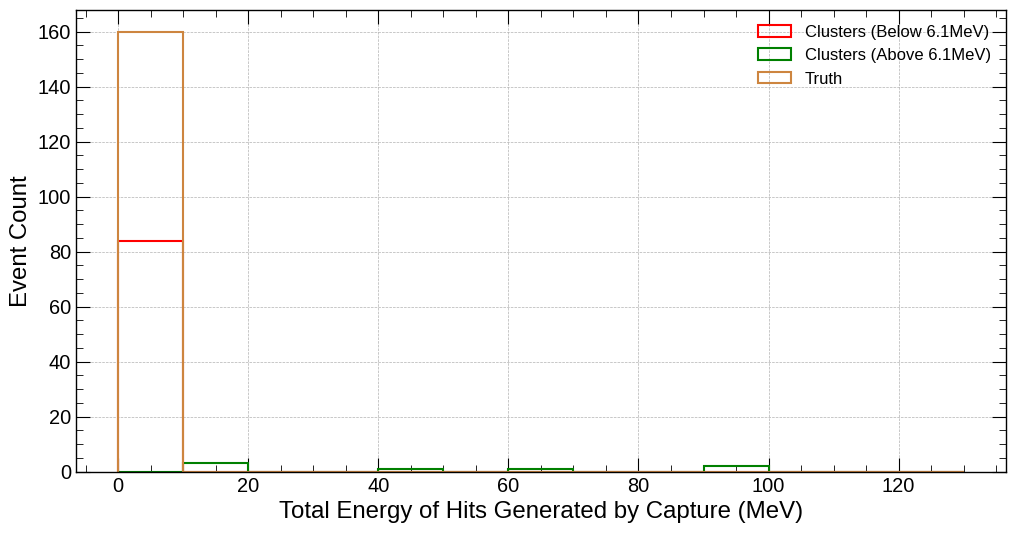

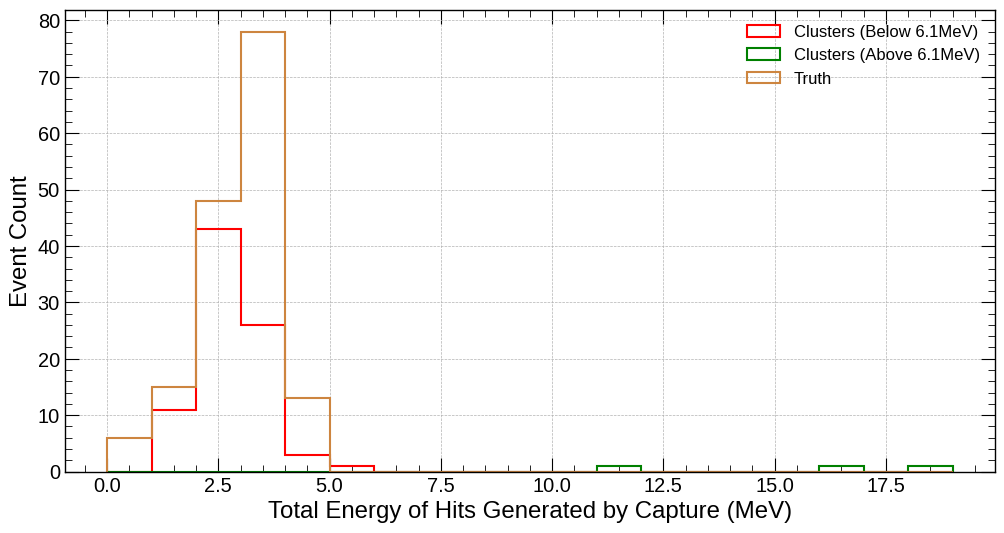

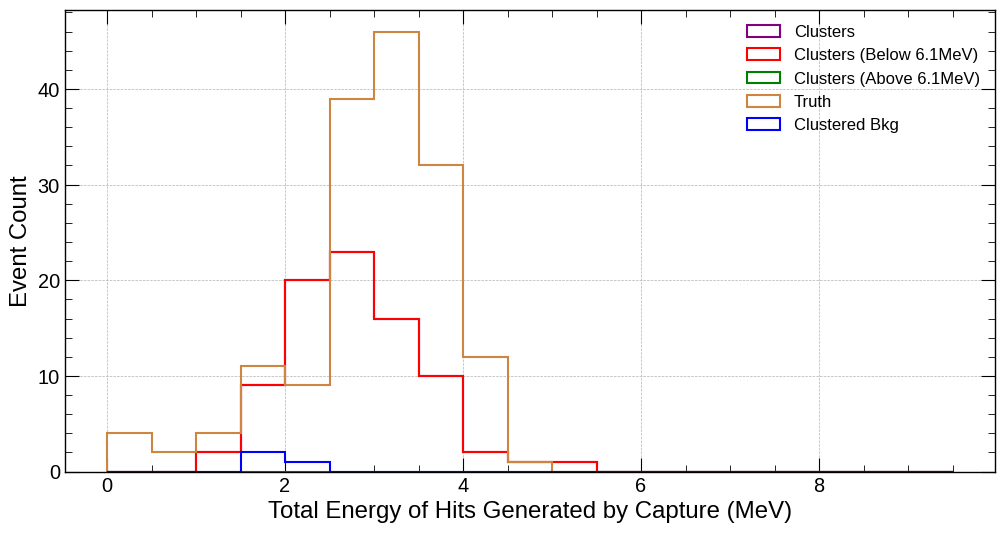

In [25]:
# Plot the energy distribution of clusters above and below the cut

plt.figure(figsize=(12, 6))

plt.hist(Ecut, color='red', histtype='step', bins=np.arange(0,140,10), label='Clusters (Below 6.1MeV)')
plt.hist(Eexc, color='green', histtype='step', bins=np.arange(0,140,10), label='Clusters (Above 6.1MeV)')
plt.hist(E_truth, color='peru', histtype='step', bins=np.arange(0,140,10), label='Truth')
#plt.hist(E_cluster_bkg, color='blue', histtype='step', bins=np.arange(0,140,10), label='Clustered Bkg')
#plt.hist(E_cluster, color='purple', histtype='step', bins=np.arange(0,140,10), label='Clusters')

plt.xlabel('Total Energy of Hits Generated by Capture (MeV)')
plt.ylabel('Event Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

# Inspect the cut
plt.figure(figsize=(12, 6))

plt.hist(Ecut, color='red', histtype='step', bins=np.arange(0,20,1), label='Clusters (Below 6.1MeV)')
plt.hist(Eexc, color='green', histtype='step', bins=np.arange(0,20,1), label='Clusters (Above 6.1MeV)')
plt.hist(E_truth, color='peru', histtype='step', bins=np.arange(0,20,1), label='Truth')
#plt.hist(E_cluster_bkg, color='blue', histtype='step', bins=np.arange(0,20,1), label='Clustered Bkg')
#plt.hist(E_cluster, color='purple', histtype='step', bins=np.arange(0,20,1), label='Clusters')

plt.xlabel('Total Energy of Hits Generated by Capture (MeV)')
plt.ylabel('Event Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))

plt.hist(E_cluster, color='purple', histtype='step', bins=np.arange(0,10,0.5), label='Clusters')
plt.hist(Ecut, color='red', histtype='step', bins=np.arange(0,10,0.5), label='Clusters (Below 6.1MeV)')
plt.hist(Eexc, color='green', histtype='step', bins=np.arange(0,10,0.5), label='Clusters (Above 6.1MeV)')
plt.hist(E_truth, color='peru', histtype='step', bins=np.arange(0,10,0.5), label='Truth')
plt.hist(E_cluster_bkg, color='blue', histtype='step', bins=np.arange(0,10,0.5), label='Clustered Bkg')

plt.xlabel('Total Energy of Hits Generated by Capture (MeV)')
plt.ylabel('Event Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,10))
plt.legend()
plt.show()